# Counting Lab: Predict vs Generate (and let the CPU sweat a little)

## 1) What we know (from the literature)
This chapter gives us two complementary superpowers:
- **Counting formulas** (predict how many objects exist without listing them).
- **Generation algorithms** (systematically *produce* permutations/combinations in lexicographic order).

It also suggests computational tasks like generating **r-permutations** and **r-combinations** (with/without repetition). :contentReference[oaicite:2]{index=2}

## 2) The problem we’re curious about
When does “just generate them” become painfully expensive?
And can we **verify** that our generators produce exactly the number of objects the formulas predict?

## 3) The gap (literature → our question)
The text provides pseudocode + formulas, but it doesn’t:
- benchmark runtime growth,
- validate generation counts at multiple sizes,
- show the “blow-up curve” in a way students feel in their bones.

## 4) The work we’ll do
We will:
1. Implement **next-permutation** and **next-r-combination** (lexicographic) based on the chapter algorithms. :contentReference[oaicite:3]{index=3}
2. Build generators that **iterate without storing everything** (so we can go bigger).
3. Compare:
   - predicted counts (math)
   - observed counts (generation)
   - runtime (how much the CPU complains)

## 5) Why we’ll believe the work
We’ll use multiple cross-checks:
- counts match known formulas,
- sequences are strictly increasing in lexicographic order,
- small cases match Python’s trusted `itertools` results.

## Goal: Implement the chapter’s lexicographic "next" building blocks

We’ll implement two primitives:

1) `next_permutation(a)`
   - mutates a permutation list `a` into the next permutation in lexicographic order
   - returns `True` if it advanced, `False` if `a` was already the last permutation

2) `next_r_combination(c, n, r)`
   - mutates a combination list `c` (length r, strictly increasing values in `[0..n-1]`)
   - returns `True` if it advanced, `False` if we hit the last combination

These correspond directly to the chapter’s algorithm blocks for generating the next permutation and next r-combination. :contentReference[oaicite:4]{index=4}

## Goal: Rewrite the "next" algorithms with expressive variable names (same behavior)

We want the same two lexicographic stepping functions:

1) `next_lexicographic_permutation(values)`
   - takes a permutation like [0, 1, 3, 2]
   - mutates it into the next permutation in lexicographic order
   - returns True if it advanced, False if it was already the last permutation

2) `next_lexicographic_combination(indices, universe_size, choose_count)`
   - takes a combination like [0, 2, 5]
   - mutates it into the next r-combination in lexicographic order
   - returns True if it advanced, False if it was already the last combination

Why we care:
- Counting formulas tell us how many objects exist.
- These "next" functions give us a *deterministic iterator* that can walk the whole space
  exactly once, in a predictable order, without recursion and without storing everything.

In [10]:
from __future__ import annotations

def next_lexicographic_permutation(permutation_values: list[int]) -> bool:
    """
    Advance `permutation_values` to the next permutation in lexicographic order.

    Returns:
        True  -> we successfully advanced to a new permutation
        False -> we were already at the last permutation (descending order)

    Key invariant (what makes it a permutation):
        The list contains each element exactly once.
    """
    last_index = len(permutation_values) - 1

    # Step 1: Find the "pivot" position (from the right) where we can increase.
    # We want the rightmost index where permutation_values[pivot] < permutation_values[pivot + 1].
    pivot_index = last_index - 1
    while pivot_index >= 0 and permutation_values[pivot_index] >= permutation_values[pivot_index + 1]:
        pivot_index -= 1

    # If no pivot exists, the list is in descending order (the last lexicographic permutation).
    if pivot_index < 0:
        return False

    # Step 2: Find the rightmost element that is bigger than the pivot element.
    # This chooses the smallest possible "increase" to stay lexicographically minimal.
    swap_index = last_index
    while permutation_values[swap_index] <= permutation_values[pivot_index]:
        swap_index -= 1

    # Step 3: Swap pivot with that element.
    permutation_values[pivot_index], permutation_values[swap_index] = (
        permutation_values[swap_index],
        permutation_values[pivot_index],
    )

    # Step 4: Reverse the suffix (the part to the right of pivot) to make it as small as possible.
    suffix_start = pivot_index + 1
    permutation_values[suffix_start:] = reversed(permutation_values[suffix_start:])

    return True


def next_lexicographic_combination(
    chosen_indices: list[int],
    universe_size: int,
    choose_count: int,
) -> bool:
    """
    Advance `chosen_indices` to the next r-combination (lexicographic) drawn from [0 .. universe_size-1].

    Representation:
        chosen_indices is a strictly increasing list of length `choose_count`.

    Returns:
        True  -> advanced to the next combination
        False -> already at the last combination

    Key invariants (what makes it a valid combination encoding):
        0 <= chosen_indices[0] < chosen_indices[1] < ... < chosen_indices[r-1] < universe_size
    """
    # Step 1: Find the rightmost position we can safely increment.
    # For position i, the maximum allowed value is:
    #     universe_size - choose_count + i
    # because we must leave enough room to fit the increasing tail.
    rightmost_movable_position = choose_count - 1
    while (
        rightmost_movable_position >= 0
        and chosen_indices[rightmost_movable_position]
        == (universe_size - choose_count + rightmost_movable_position)
    ):
        rightmost_movable_position -= 1

    # If we couldn't find a movable position, we're at the last combination.
    if rightmost_movable_position < 0:
        return False

    # Step 2: Increment that position...
    chosen_indices[rightmost_movable_position] += 1

    # Step 3: ...and "pack" everything to the right as tightly as possible
    # to get the next lexicographic combination.
    for position in range(rightmost_movable_position + 1, choose_count):
        chosen_indices[position] = chosen_indices[position - 1] + 1

    return True

### Why these variable names matter (and what this teaches)

These algorithms are *counting-adjacent*, even though they "generate":
- The math tells us **how many** objects exist.
- The generator tells us **how to visit** each object exactly once.

If your variable names are vague (`a`, `j`, `k`), students memorize steps.
If your variable names are meaningful (`pivot_index`, `swap_index`, `suffix_start`),
students learn *the idea*.

---

## Permutations: what the names reveal

### `pivot_index`
This is the "place where we can still go up".
If no pivot exists, we're already at the maximum permutation:
- descending order means "nothing can increase anymore".

### `swap_index`
We want the smallest increase, so we swap pivot with the rightmost element
that is still larger than the pivot.

### `suffix_start` + reverse
After increasing the prefix slightly, we reset the rest to the smallest possible order.
That's why we reverse the suffix: it becomes the minimal tail.

**Big concept:**
We change the permutation by the smallest amount needed to get the *next* one.
That’s lexicographic stepping.

---

## Combinations: what the names reveal

### `rightmost_movable_position`
Combinations are encoded as increasing indices.
We search from the right because we want the *next* combination with the smallest change.

### maximum allowed value: `universe_size - choose_count + i`
That formula is the "leave room for the tail" rule.
If you pick too large a value at position i, you can't finish an increasing list of length r.

### "pack the tail"
After we bump one index, we set the following indices to the smallest possible increasing values.
This prevents gaps and guarantees lexicographic order.

---

## How this ties to counting
These "next" functions are the computational twin of the counting formulas:

- counting: "There are C(n, r) combinations."
- generation: "Here is a deterministic way to visit all C(n, r) combinations exactly once."

So when we run an experiment:
- predicted count from formula
- observed count from generator

...agreement means we have strong evidence both the math and the code line up.

### Details: how these functions meet the goal

#### `next_permutation(a)`
This is the classic lexicographic stepper:
- Find the "pivot" where the sequence stops increasing from the right.
- Swap pivot with the smallest larger element to its right.
- Reverse the suffix to get the smallest possible tail.

That produces the *next* permutation without skipping or repeating.

#### `next_r_combination(c, n, r)`
An r-combination is a strictly increasing list of indices.
We:
- scan from the right for an index that can still move up,
- increment it,
- then “pack” everything to its right as tightly as possible.

Result: combinations progress in lexicographic order and cover the whole space exactly once.

## Goal: Build generators for permutations and combinations (memory-friendly)

We’ll create:
- `gen_permutations(n)` yielding permutations of `[0..n-1]` in lexicographic order
- `gen_combinations(n, r)` yielding r-combinations of `[0..n-1]`

Key idea:
- We **yield one at a time**, and we never keep the full list in memory.
That lets us push size until the CPU starts writing poetry in heatwaves.

In [11]:
def gen_permutations(n: int):
    a = list(range(n))  # start with smallest lexicographic
    yield tuple(a)
    while next_permutation(a):
        yield tuple(a)

def gen_combinations(n: int, r: int):
    if not (0 <= r <= n):
        return
    c = list(range(r))  # smallest combination
    yield tuple(c)
    while next_r_combination(c, n, r):
        yield tuple(c)

## Goal: Compare predicted counts vs observed counts, and measure runtime

We will compute for a grid of sizes:
- **Predicted count**
  - permutations: `n!`
  - combinations: `C(n, r)`
- **Observed count** by iterating the generator (but not storing outputs)
- **Runtime** with `time.perf_counter()`

Then we’ll plot runtime vs predicted count to visualize blow-up.

This connects the “counting formulas” mindset to the “generation algorithms” mindset,
which the chapter frames as complementary tools for solving counting problems. :contentReference[oaicite:5]{index=5}

In [12]:
import time
import math
import pandas as pd
import matplotlib.pyplot as plt

def consume_count(gen):
    """Count items in a generator without storing them, with a tiny checksum to avoid 'dead code' effects."""
    count = 0
    checksum = 0
    for item in gen:
        count += 1
        # checksum: cheap, deterministic, makes sure we're touching the data
        checksum ^= hash(item)
    return count, checksum

rows = []

# --- combinations benchmark ---
n = 30
for r in [2, 4, 6, 8, 10, 12, 15]:
    predicted = math.comb(n, r)
    t0 = time.perf_counter()
    observed, checksum = consume_count(gen_combinations(n, r))
    t1 = time.perf_counter()
    rows.append({
        "type": "combination",
        "n": n,
        "r": r,
        "predicted_count": predicted,
        "observed_count": observed,
        "seconds": t1 - t0,
        "checksum": checksum
    })

# --- permutations benchmark ---
# Keep this modest by default; n=10 means 3,628,800 permutations (noticeable CPU time).
for n in [7, 8, 9]:
    predicted = math.factorial(n)
    t0 = time.perf_counter()
    observed, checksum = consume_count(gen_permutations(n))
    t1 = time.perf_counter()
    rows.append({
        "type": "permutation",
        "n": n,
        "r": None,
        "predicted_count": predicted,
        "observed_count": observed,
        "seconds": t1 - t0,
        "checksum": checksum
    })

df = pd.DataFrame(rows)
df

,type,n,r,predicted_count,observed_count,seconds,checksum
0,combination,30,2.0,435,435,0.000124,5776175208690956225
1,combination,30,4.0,27405,27405,0.007175,-5238717125775691865
2,combination,30,6.0,593775,593775,0.165666,-5538723321510800773
3,combination,30,8.0,5852925,5852925,1.698166,5443923856122789509
4,combination,30,10.0,30045015,30045015,9.125151,255246889680397120
5,combination,30,12.0,86493225,86493225,29.128703,-3763572419790423436
6,combination,30,15.0,155117520,155117520,60.586830,-8897573278077861521
7,permutation,7,NaN,5040,5040,0.002471,1447764848202905913
8,permutation,8,NaN,40320,40320,0.020086,4344224994681111515
9,permutation,9,NaN,362880,362880,0.181295,-6526065209366183222


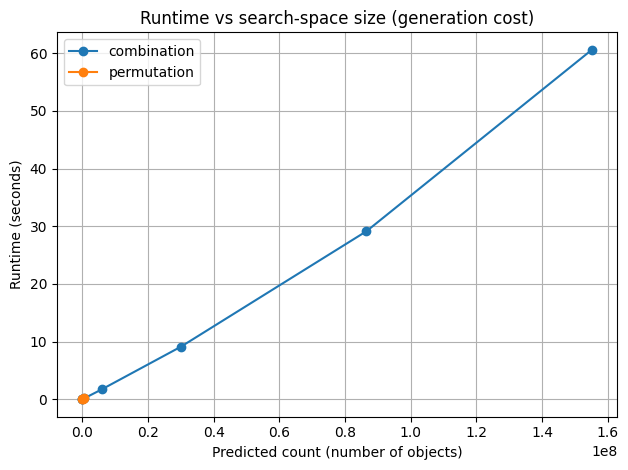

In [13]:
# Plot BOTH types on the same axes
plt.figure()
for t in ["combination", "permutation"]:
    sub = df[df["type"] == t].sort_values("predicted_count")
    plt.plot(sub["predicted_count"], sub["seconds"], marker="o", label=t)

plt.xlabel("Predicted count (number of objects)")
plt.ylabel("Runtime (seconds)")
plt.title("Runtime vs search-space size (generation cost)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Why we believe our work

### 1) Count agreement (the big one)
For each experiment we computed:
- `predicted_count` from math (n!, C(n,r))
- `observed_count` from generation

If the generator is correct, these match exactly.
Any mismatch is a red siren: skipped items, duplicates, or termination errors.

### 2) Structural invariants
- Permutations always contain each number 0..n-1 exactly once.
- Combinations are strictly increasing and stay within 0..n-1.
- Lexicographic progression avoids repeats and guarantees coverage.

### 3) “Independent verification” idea (optional next step)
For small n/r, we can compare our outputs against `itertools.permutations` and `itertools.combinations`.
That gives us a second, trusted implementation to cross-check.

### 4) The lesson students feel
Counting formulas tell us *how many exist*.
Generation algorithms show us *what it costs to enumerate them*.
When the predicted count jumps by 10×, runtime tends to follow, like a loyal (and slightly angry) shadow.

In [14]:
# HEAT MODE: be kind to your laptop fans 😄
# n=10 => 3,628,800 permutations
# n=11 => 39,916,800 permutations (this can be a LOT in pure Python)

import time, math

n = 10
predicted = math.factorial(n)
print("n =", n, "predicted permutations =", predicted)

t0 = time.perf_counter()
observed, checksum = consume_count(gen_permutations(n))
t1 = time.perf_counter()

print("observed =", observed)
print("seconds  =", t1 - t0)
print("checksum =", checksum)

n = 10 predicted permutations = 3628800
observed = 3628800
seconds  = 1.8794602999987546
checksum = 2746834466973419971
